In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../../data/02-cleaned/cleaned_data.csv")

df = df.rename(
    columns={
        "tkt_code": "remision",
        "order_date": "fecha_del_pedido",
        "order_code": "numero_de_pedido",
        "start_time": "hora_comprometida",
        "truck_code": "numero_de_camion",
        "u_volumen": "volumen",
        "typed_time": "hora_de_carga",
        "at_plant_time": "hora_de_regreso",
        "u_cicle": "ciclo",
        "name": "cliente",
        "nombredelproyecto": "nombre_del_proyecto",
        "ship_addr_line": "direccion",
    }
)

df = df.drop(columns="ship_plant_code", errors="ignore")

dt_cols = ["fecha_del_pedido", "hora_comprometida", "hora_de_carga", "hora_de_regreso"]
for c in dt_cols:
    df[c] = pd.to_datetime(df[c], format="mixed", errors="coerce")

num_cols_float = ["volumen"]
num_cols_int = ["año", "remision", "numero_de_pedido", "numero_de_camion", "ciclo"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

for c in num_cols_float + num_cols_int:
    df[c] = pd.to_numeric(df[c], errors="coerce")

required_cols = dt_cols + [
    "remision",
    "numero_de_pedido",
    "numero_de_camion",
    "ciclo",
    "volumen",
]

mask_ok = df[required_cols].notna().all(axis=1)

mask_ok &= (df["volumen"] > 0) & (df["volumen"] < 50)
mask_ok &= (df["ciclo"] > 0) & (df["ciclo"] < 600)

df = df.loc[mask_ok].copy()

df[num_cols_int] = df[num_cols_int].round().astype("int64")

df["hora"] = df["hora_comprometida"].dt.hour.astype("int64")
df["mes"] = df["hora_comprometida"].dt.month.astype("int64")
df["dia_semana"] = df["hora_comprometida"].dt.day_name()

df["retraso_min"] = (
    df["hora_de_carga"] - df["hora_comprometida"]
).dt.total_seconds() / 60

df.info()

<class 'pandas.DataFrame'>
Index: 35335 entries, 0 to 35336
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   año                  35335 non-null  int64         
 1   remision             35335 non-null  int64         
 2   fecha_del_pedido     35335 non-null  datetime64[us]
 3   numero_de_pedido     35335 non-null  int64         
 4   hora_comprometida    35335 non-null  datetime64[us]
 5   numero_de_camion     35335 non-null  int64         
 6   volumen              35335 non-null  float64       
 7   hora_de_carga        35335 non-null  datetime64[us]
 8   hora_de_regreso      35335 non-null  datetime64[us]
 9   ciclo                35335 non-null  int64         
 10  cliente              35335 non-null  str           
 11  nombre_del_proyecto  35335 non-null  str           
 12  direccion            35324 non-null  str           
 13  hora                 35335 non-null  int64     

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Patrones de Demanda

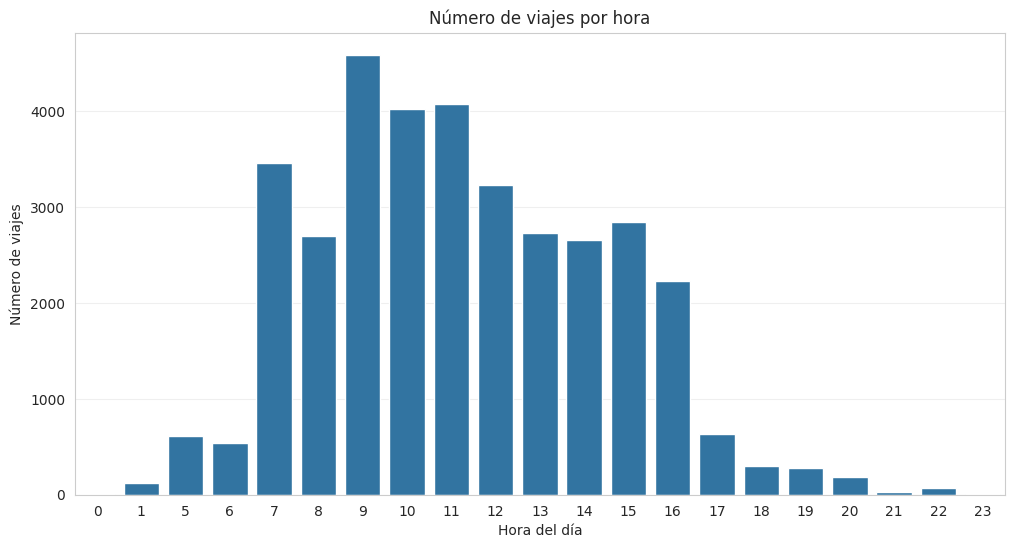

In [4]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="hora",
)

plt.title("Número de viajes por hora")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes")

plt.grid(axis="y", alpha=0.3)
plt.savefig("numero_de_viajes_por_hora.png")

plt.show()

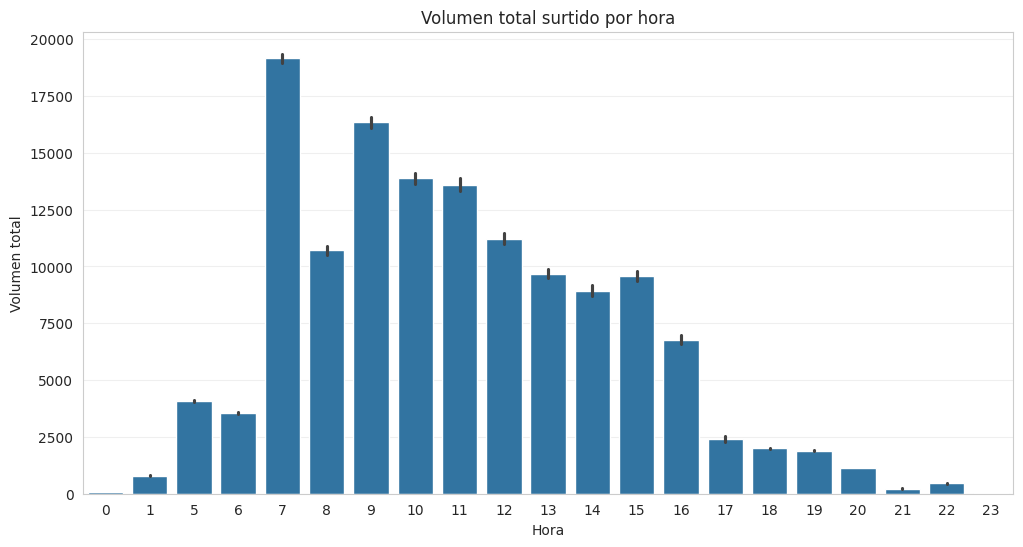

In [5]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="hora",
    y="volumen",
    estimator=sum,
)

plt.title("Volumen total surtido por hora")
plt.xlabel("Hora")
plt.ylabel("Volumen total")

plt.grid(axis="y", alpha=0.3)
plt.savefig("volumen_total_surtido_por_hora.png")
plt.show()

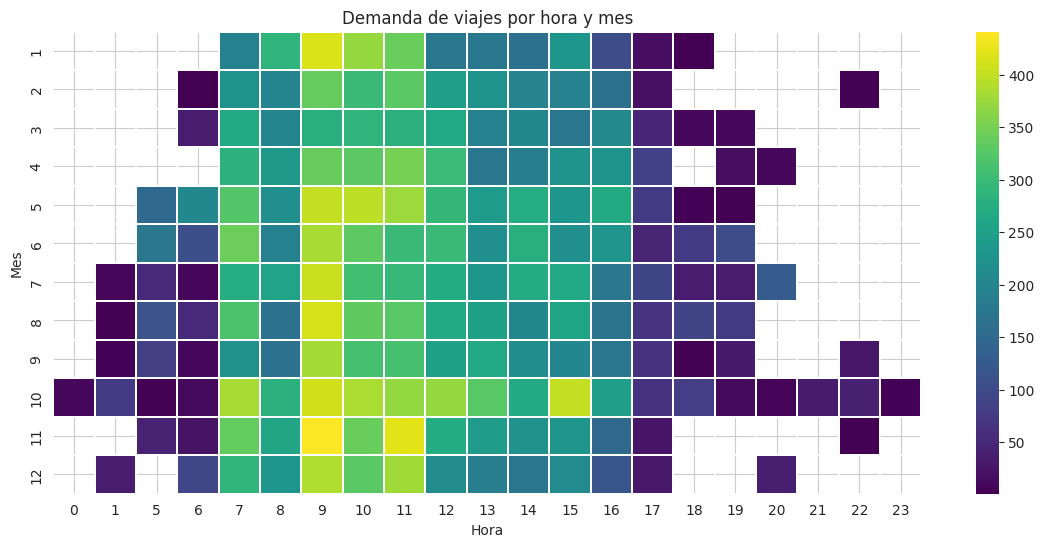

In [6]:
pivot = df.pivot_table(index="mes", columns="hora", values="remision", aggfunc="count")

plt.figure(figsize=(14, 6))

sns.heatmap(pivot, cmap="viridis", linewidths=0.3)

plt.title("Demanda de viajes por hora y mes")
plt.xlabel("Hora")
plt.ylabel("Mes")

plt.savefig("demanda_de_viajes_por_hora_y_mes.png")
plt.show()

# Calidad del Servicio (Retrasos)

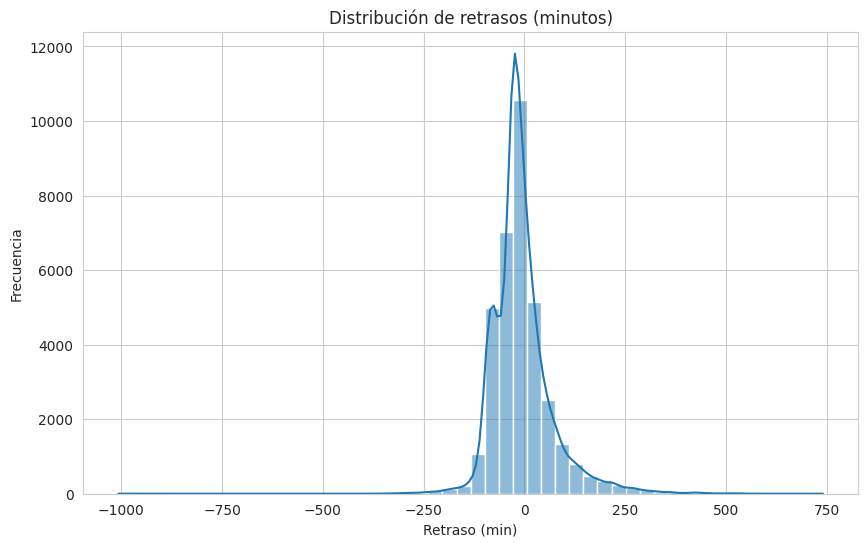

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["retraso_min"],
    bins=50,
    kde=True,
)

plt.title("Distribución de retrasos (minutos)")
plt.xlabel("Retraso (min)")
plt.ylabel("Frecuencia")

plt.savefig("distribucion_de_retrasos_(minutos).png")
plt.show()

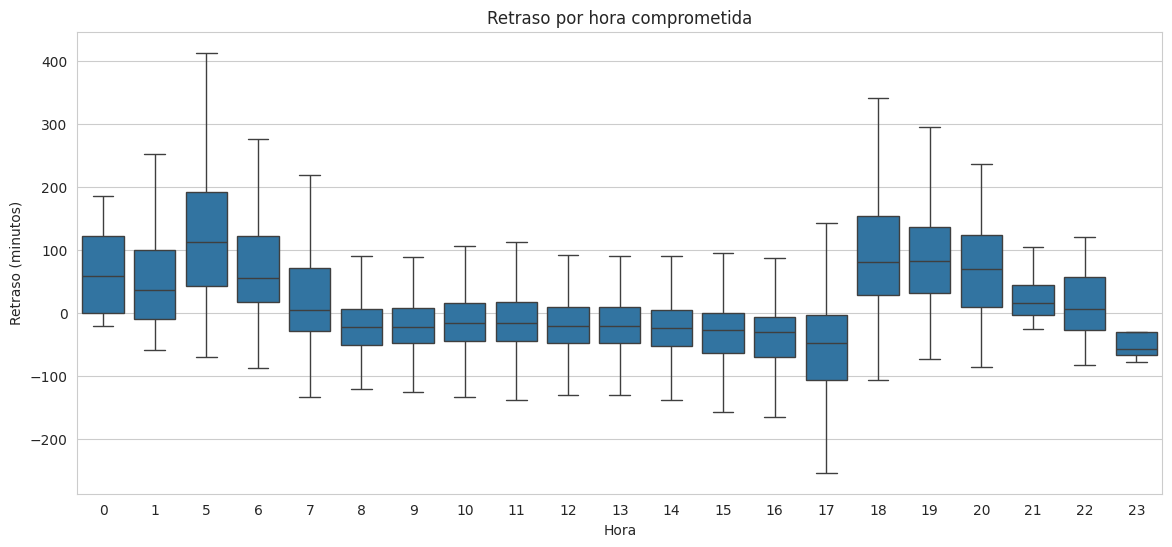

In [8]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="hora",
    y="retraso_min",
    showfliers=False,
)

plt.title("Retraso por hora comprometida")
plt.xlabel("Hora")
plt.ylabel("Retraso (minutos)")

plt.savefig("retraso_por_hora_comprometida.png")
plt.show()

# Eficiencia Operacional

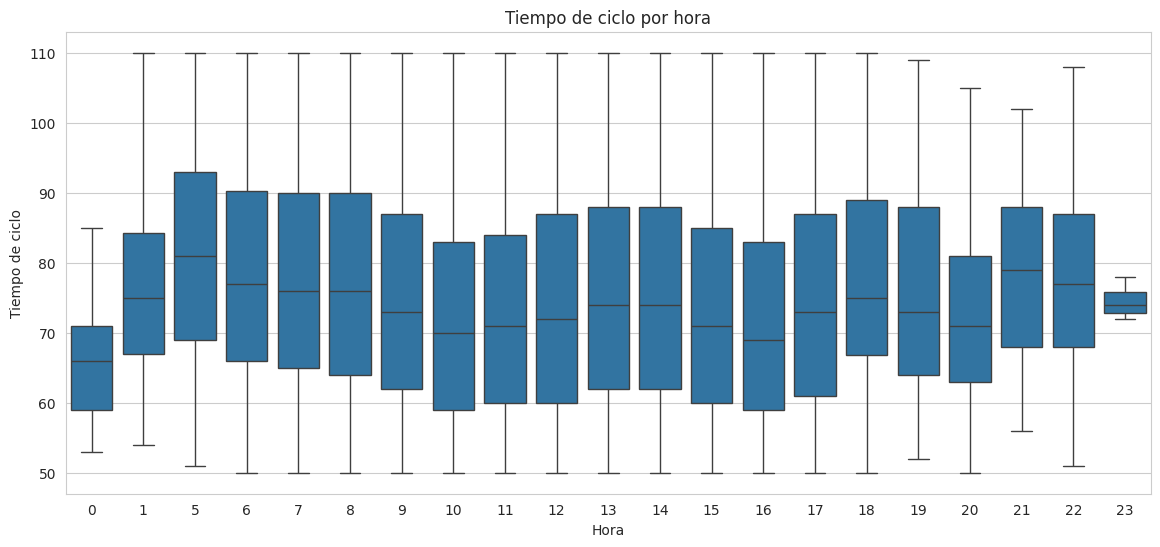

In [9]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="hora",
    y="ciclo",
    showfliers=False,
)

plt.title("Tiempo de ciclo por hora")
plt.xlabel("Hora")
plt.ylabel("Tiempo de ciclo")

plt.savefig("tiempo_de_ciclo_por_hora.png")
plt.show()

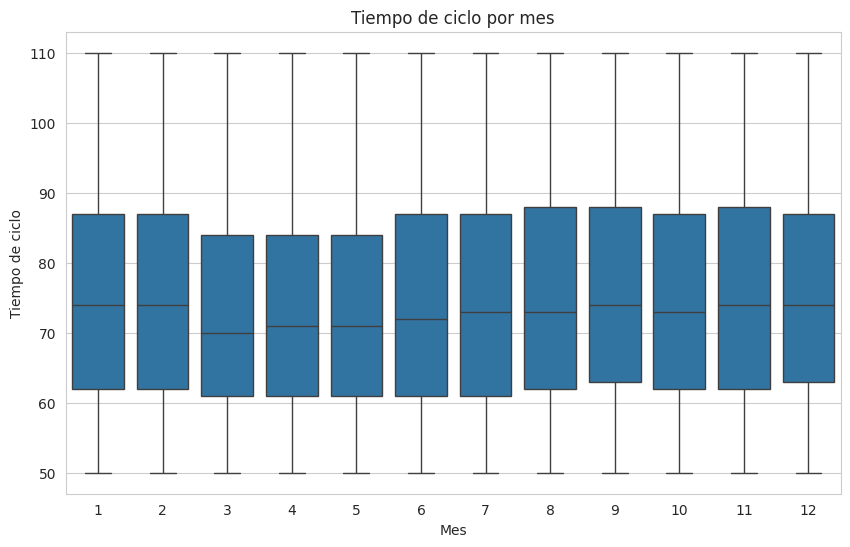

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="mes",
    y="ciclo",
    showfliers=False,
)

plt.title("Tiempo de ciclo por mes")
plt.xlabel("Mes")
plt.ylabel("Tiempo de ciclo")

plt.savefig("tiempo_de_ciclo_por_mes.png")
plt.show()

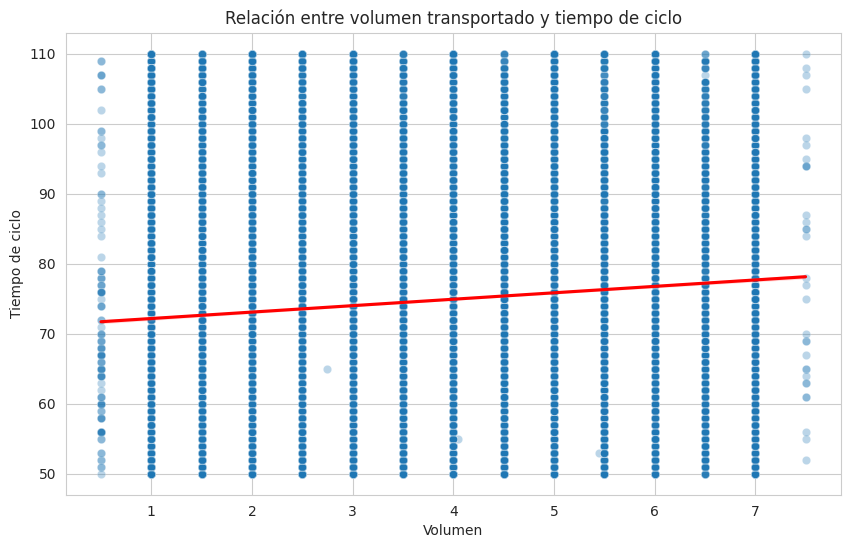

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="volumen", y="ciclo", alpha=0.3)

sns.regplot(data=df, x="volumen", y="ciclo", scatter=False, color="red")

plt.title("Relación entre volumen transportado y tiempo de ciclo")
plt.xlabel("Volumen")
plt.ylabel("Tiempo de ciclo")

plt.savefig("relacion_entre_volument_transportado_y_tiempo_de_ciclo.png")
plt.show()

# Uso de Flota

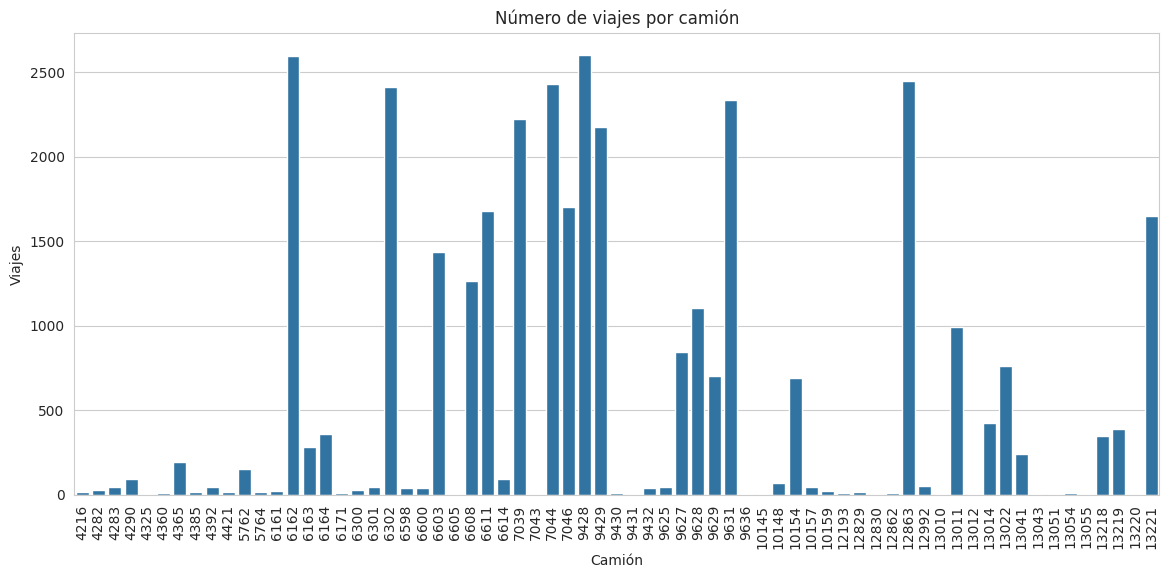

In [12]:
truck_trips = df.groupby("numero_de_camion").size().reset_index(name="viajes")

plt.figure(figsize=(14, 6))

sns.barplot(
    data=truck_trips,
    x="numero_de_camion",
    y="viajes",
)

plt.title("Número de viajes por camión")
plt.xlabel("Camión")
plt.ylabel("Viajes")

plt.savefig("numero_de_viajes_por_camion.png")
plt.xticks(rotation=90)
plt.show()

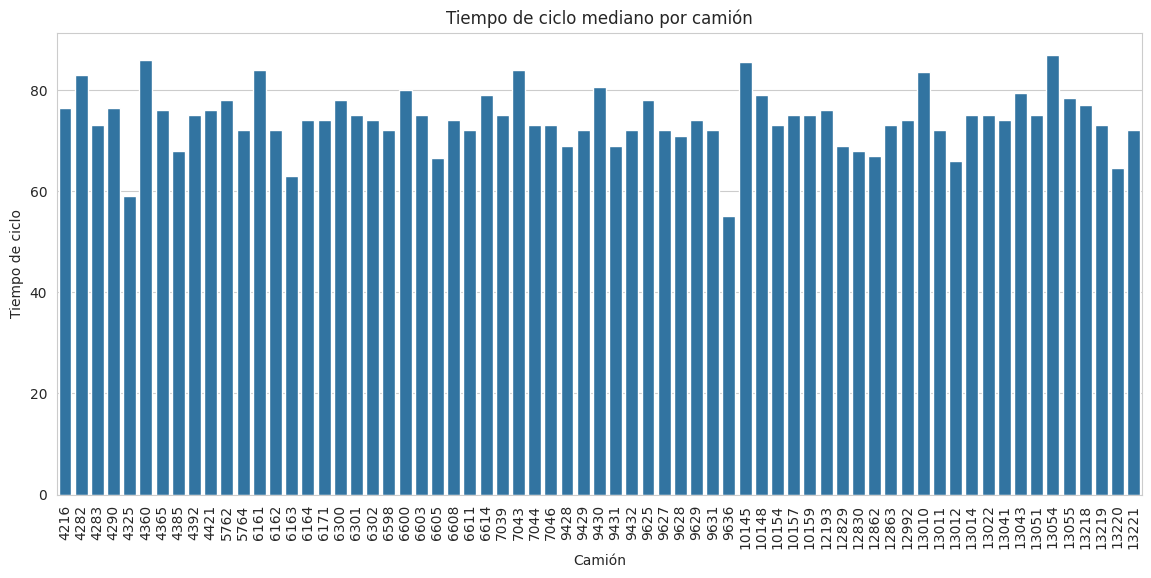

In [13]:
truck_cycle = df.groupby("numero_de_camion")["ciclo"].median().reset_index()

plt.figure(figsize=(14, 6))

sns.barplot(
    data=truck_cycle,
    x="numero_de_camion",
    y="ciclo",
)

plt.title("Tiempo de ciclo mediano por camión")
plt.xlabel("Camión")
plt.ylabel("Tiempo de ciclo")

plt.savefig("tiempo_de_ciclo_mediano_por_camion.png")
plt.xticks(rotation=90)
plt.show()